# 타이타닉 생존자 예측

## 데이터 분석해보기 EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn')  # 이미지가 seaborn스타일로 나온다. 
sns.set(font_scale=2.5)

import missingno as msno

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 그래프를 바로 인라인으로 띄우기
%matplotlib inline  

In [2]:
df_train = pd.read_csv('../input/c/titanic/train.csv')
df_test = pd.read_csv('../input/c/titanic/test.csv')

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
# 각 컬럼별로 결측치의 비율을 출력
for col in df_train.columns:
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_train[col].isnull().sum() / df_train[col].shape[0]))
    print(msg)

column: PassengerId	 Percent of NaN value: 0.00%
column:   Survived	 Percent of NaN value: 0.00%
column:     Pclass	 Percent of NaN value: 0.00%
column:       Name	 Percent of NaN value: 0.00%
column:        Sex	 Percent of NaN value: 0.00%
column:        Age	 Percent of NaN value: 19.87%
column:      SibSp	 Percent of NaN value: 0.00%
column:      Parch	 Percent of NaN value: 0.00%
column:     Ticket	 Percent of NaN value: 0.00%
column:       Fare	 Percent of NaN value: 0.00%
column:      Cabin	 Percent of NaN value: 77.10%
column:   Embarked	 Percent of NaN value: 0.22%


In [7]:
# 각 컬럼별로 결측치의 비율을 출력
for col in df_test.columns:
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_test[col].isnull().sum() / df_test[col].shape[0]))
    print(msg)

column: PassengerId	 Percent of NaN value: 0.00%
column:     Pclass	 Percent of NaN value: 0.00%
column:       Name	 Percent of NaN value: 0.00%
column:        Sex	 Percent of NaN value: 0.00%
column:        Age	 Percent of NaN value: 20.57%
column:      SibSp	 Percent of NaN value: 0.00%
column:      Parch	 Percent of NaN value: 0.00%
column:     Ticket	 Percent of NaN value: 0.00%
column:       Fare	 Percent of NaN value: 0.24%
column:      Cabin	 Percent of NaN value: 78.23%
column:   Embarked	 Percent of NaN value: 0.00%


<AxesSubplot:>

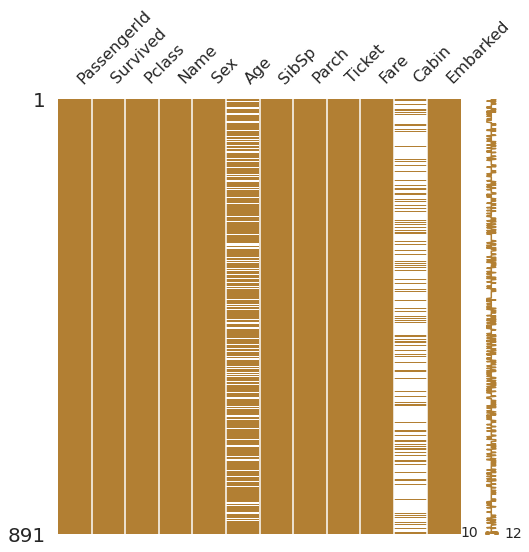

In [8]:
# 결측치의 위치를 그래프로 표
msno.matrix(df=df_train.iloc[:, :], figsize=(8, 8), color=(0.7, 0.5, 0.2))

<AxesSubplot:>

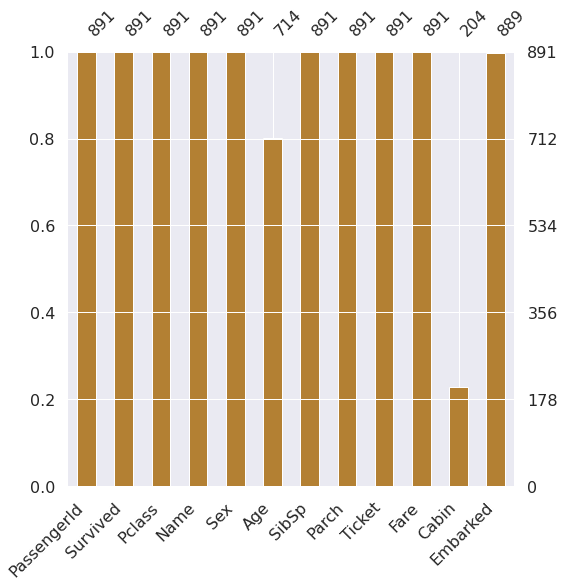

In [9]:
# 결측치의 양을 그래프로 표
msno.bar(df=df_train.iloc[:, :], figsize=(8, 8), color=(0.7, 0.5, 0.2))

타겟 레이블을 확인해야 한다. 지금 우리 모델은 생존여부를 파악하는 모델이다. 만약 훈련데이터의 샘플이 100개인데 여기서 생존한 샘플은 1개 밖에 없다고 하면 모델은 100명 모두 사망했다고 예측해도 99%의 정확도를 보인다. 타겟 레이블이 생존 1, 사망 99로 크게 불균형하기 때문이다. 이런 문제를 예방하고자 처음에 타겟레이블의 분포를 잘 살펴야 한다.

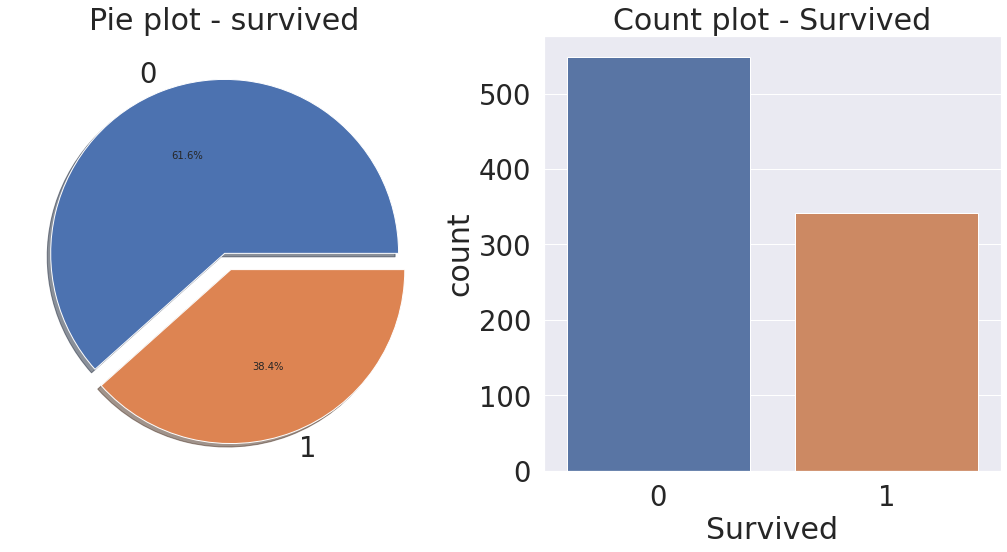

In [10]:
# 타겟 레이블 분포 확인

# subplots(행, 열, figsize=(행, 열))
f, ax =plt.subplots(1, 2, figsize=(18, 8))

# 원 그래프
df_train['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Pie plot - survived')
ax[0].set_ylabel('')

# 막대 그래프
sns.countplot('Survived', data=df_train, ax=ax[1])
ax[1].set_title('Count plot - Survived')
plt.show()

## 2.1 Pclass

In [11]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).count()

,Survived
Pclass,
1,216
2,184
3,491


In [12]:
# 컬럼 여러 개를 선택할 때는 2차원 리스트로 
df_train[['Pclass', 'Survived']]
df_train[['Pclass', 'Survived']].groupby(['Pclass'])
# 'Pclass'의 1,2,3 등급마다 각각'Survived'의 샘플 수를 카운트
df_train[['Pclass', 'Survived']].groupby(['Pclass']).count()
# 'Pclass'의 1,2,3 등급마다 각각'Survived'데이터를 더한다.
df_train[['Pclass', 'Survived']].groupby(['Pclass']).sum()

,Survived
Pclass,
1,136
2,87
3,119


In [13]:
# 클래스 마다 생존여부를 각각 카운트
# 마진 트루로 총 합을 표시한다.
pd.crosstab(df_train['Pclass'], df_train['Survived'], margins=True).style.background_gradient(cmap='Reds')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


In [14]:
# 클래스 별 생존률
# 클래스 마다 총 갯수에서 1(생존)의 비율이니까 생존률이 된다.
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


<AxesSubplot:xlabel='Pclass'>

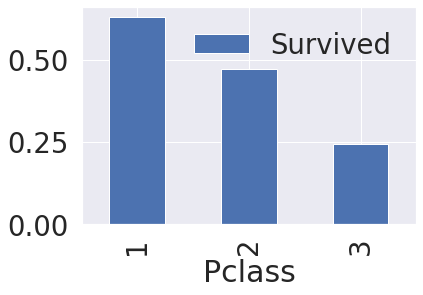

In [15]:
# 클래스 별 생존률 그래프
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).mean().plot.bar()

<AxesSubplot:xlabel='Pclass'>

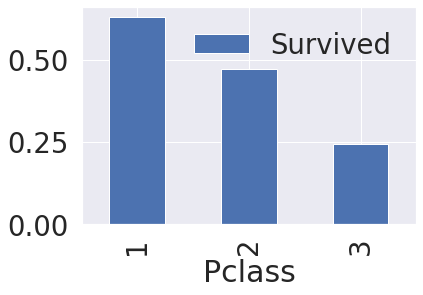

In [16]:
# .sort_values(by='Survived', ascending=False) 생존을 기준으로 정렬한다. 어센딩에 따라 내림차순, 오름차순이 바뀐다.
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).mean().sort_values(by='Survived', ascending=False).plot.bar()

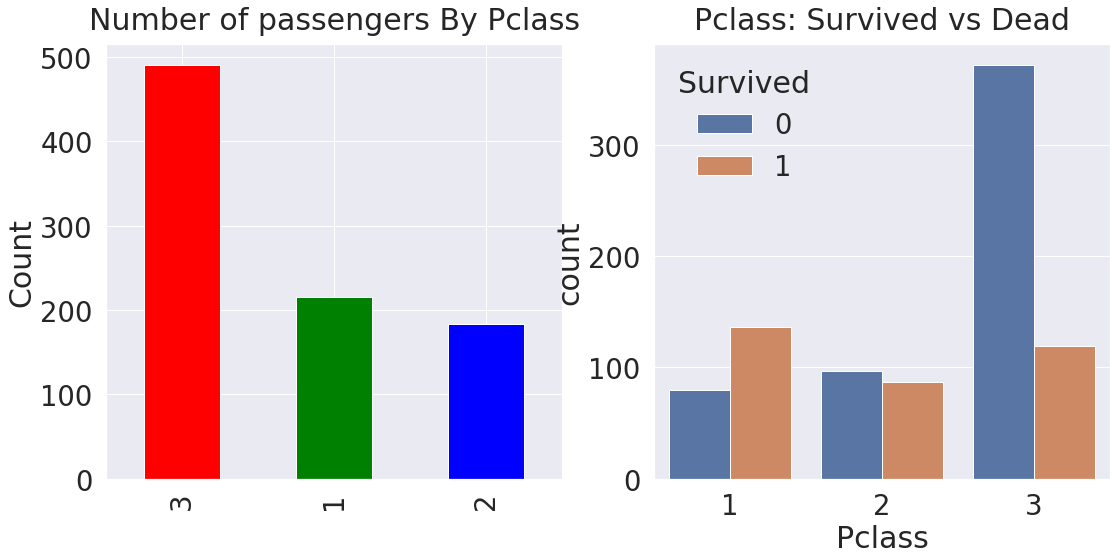

In [17]:
y_position = 1.02
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# 클래스 별로 카운트를 표시
df_train['Pclass'].value_counts().plot.bar(color=['red', 'green', 'blue'],ax=ax[0])
ax[0].set_title('Number of passengers By Pclass', y=y_position)
ax[0].set_ylabel('Count')

# 클래스 별로 생존과 사망을 구분해서 표시
sns.countplot('Pclass', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('Pclass: Survived vs Dead', y=y_position)
plt.show()

## 2.2 Sex

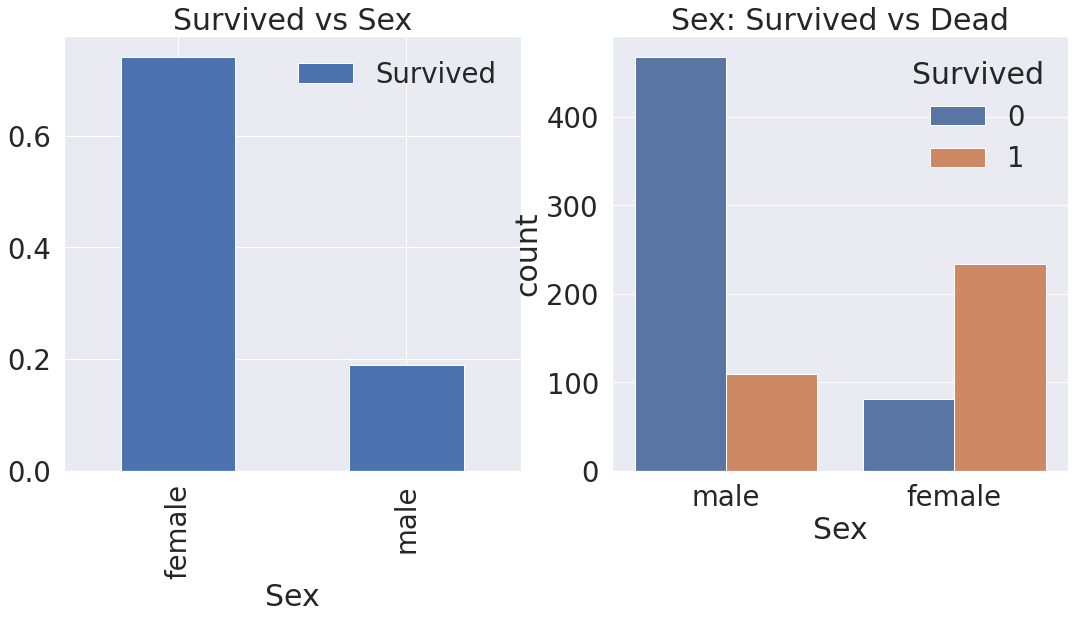

In [18]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# 성별별 생존율
df_train[['Sex', 'Survived']].groupby(['Sex'], as_index=True).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')

# 성별별 생존과 사망 수
sns.countplot('Sex', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('Sex: Survived vs Dead')
plt.show()

### 해보기! 클래스별로 남성과 여성의 생존률 그래프 그리기

In [19]:
pd.crosstab(df_train['Sex'], df_train['Survived'], margins=True).style.background_gradient(cmap='Blues')

Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


2.2 Both Sex and Pclass

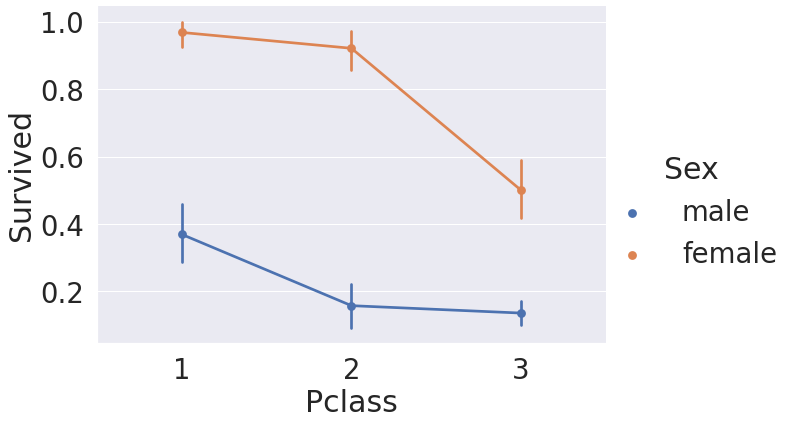

In [20]:
sns.factorplot('Pclass', 'Survived', hue='Sex', data=df_train, size=6, aspect=1.5)

- 어떤 클래스든 여성은 남성보다 생존률이 높다.
- 클래스가 높을 수록 생존률이 높아진다.

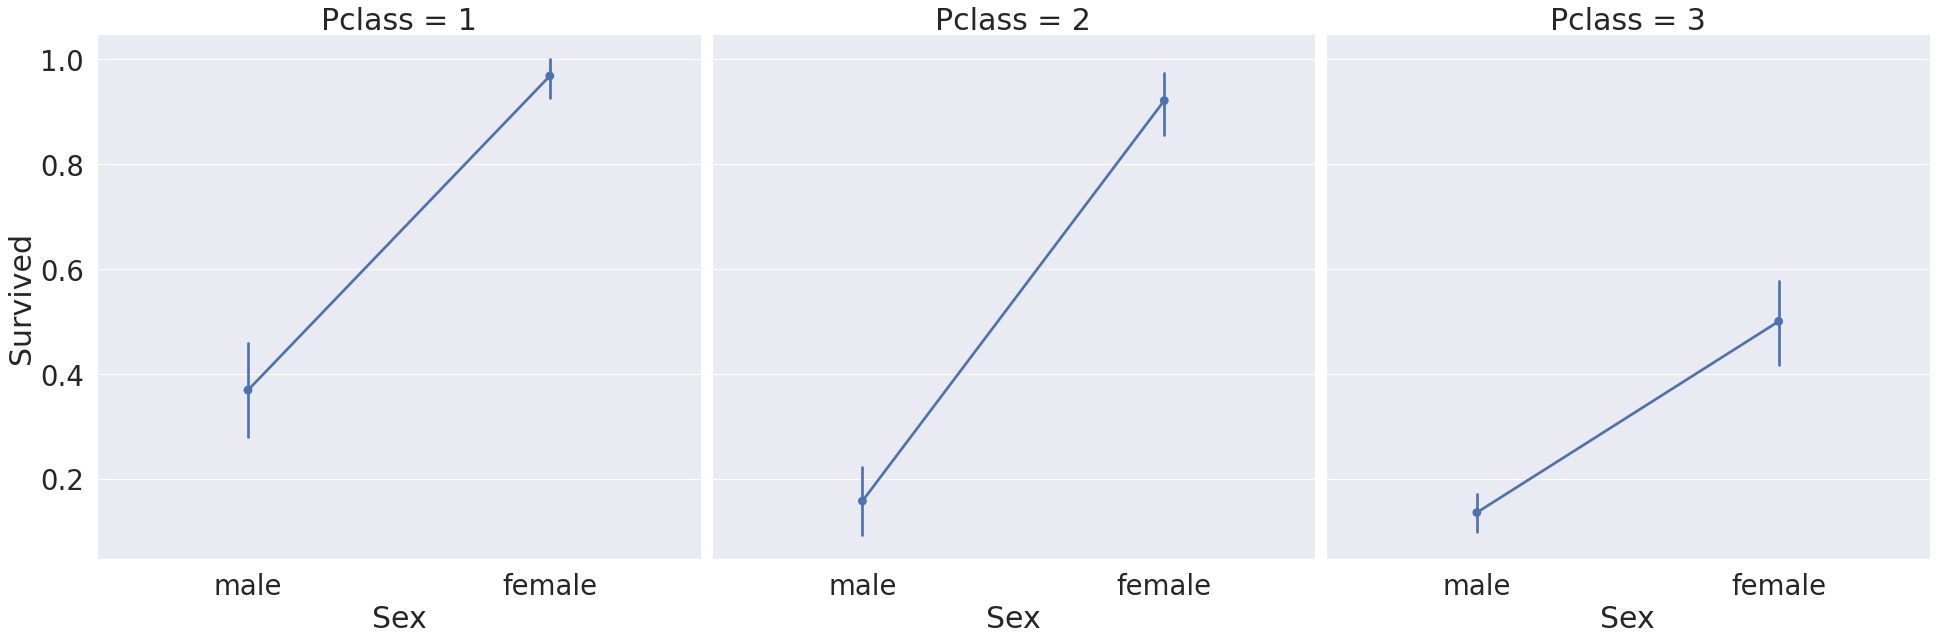

In [21]:
sns.factorplot(x='Sex', y='Survived', col='Pclass', data=df_train, saturation=5, size=9, aspect=1)

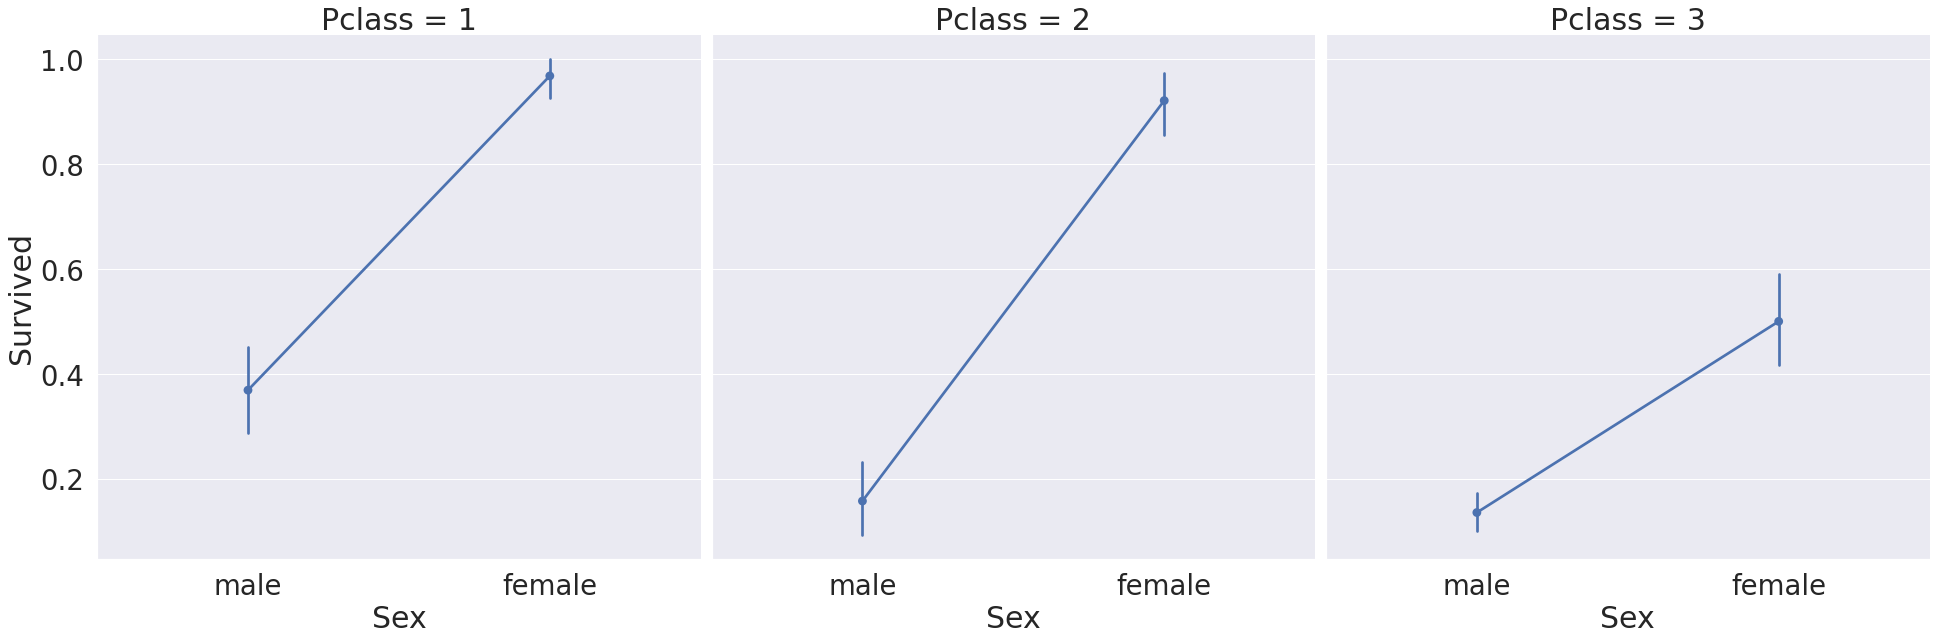

In [22]:
sns.factorplot(x='Sex', y='Survived', col='Pclass', data=df_train, size=9)

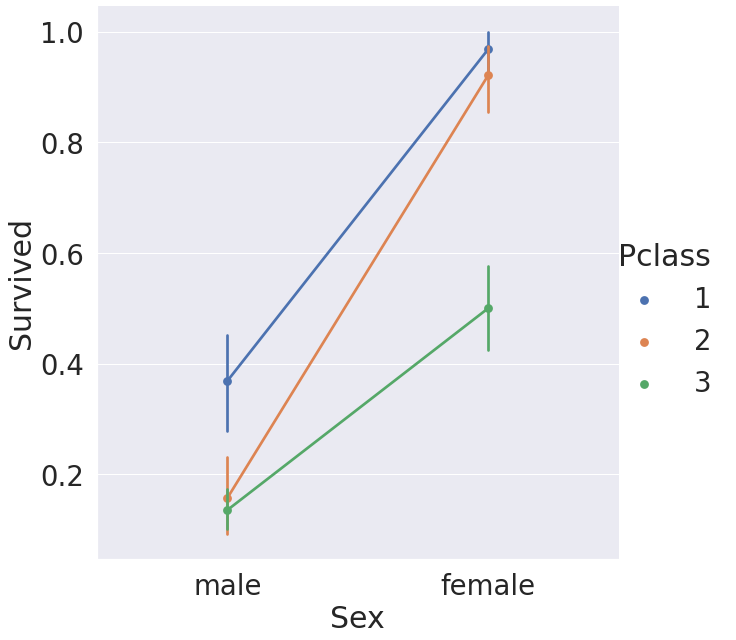

In [23]:
sns.factorplot(x='Sex', y='Survived', hue='Pclass', data=df_train, saturation=5, size=9, aspect=1)

## 2.3 Age

In [24]:
print('제일 나이 많은 탑승객 : {:.1f}세'.format(df_train['Age'].max()))
print('제일 어린 탑승객 : {:.1f}세'.format(df_train['Age'].min()))
print('탑승객 평균 나이 : {:.1f}세'.format(df_train['Age'].mean()))

제일 나이 많은 탑승객 : 80.0세
제일 어린 탑승객 : 0.4세
탑승객 평균 나이 : 29.7세


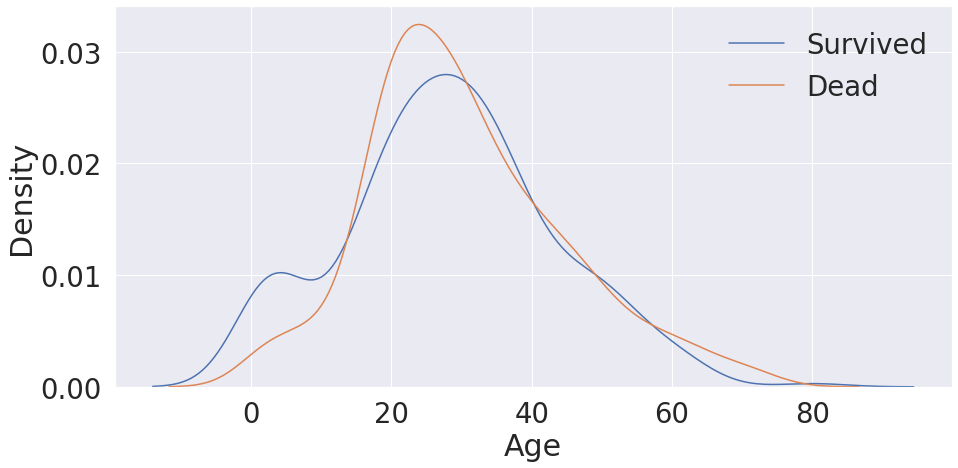

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))

# 생존자와 사망자의 나이분포를 그래프로 표시
# 생존자
sns.kdeplot(df_train[df_train['Survived'] == 1]['Age'], ax=ax)
# 사망자
sns.kdeplot(df_train[df_train['Survived'] == 0]['Age'], ax=ax)
plt.legend(['Survived', 'Dead'])
plt.show()

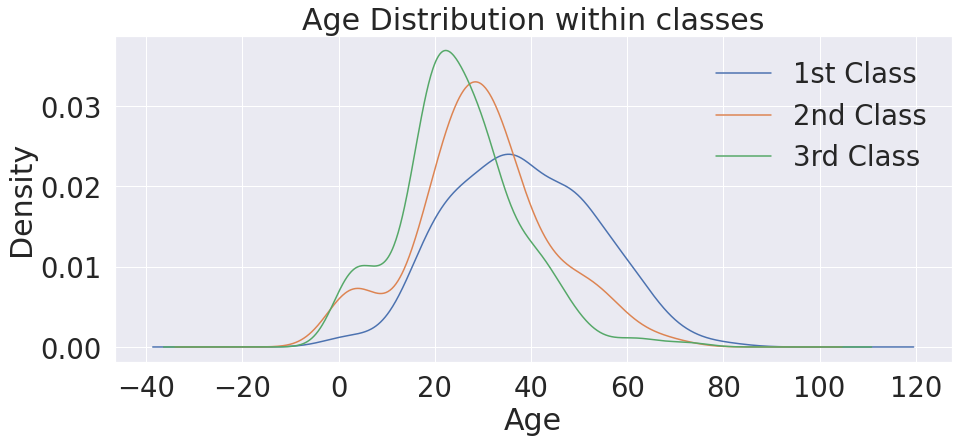

In [26]:
# 클래스별 나이 분포도

plt.figure(figsize=(15, 6))
df_train['Age'][df_train['Pclass'] == 1].plot(kind='kde')
df_train['Age'][df_train['Pclass'] == 2].plot(kind='kde')
df_train['Age'][df_train['Pclass'] == 3].plot(kind='kde')

plt.xlabel('Age')
plt.title('Age Distribution within classes')
plt.legend(['1st Class', '2nd Class', '3rd Class'])
plt.show()

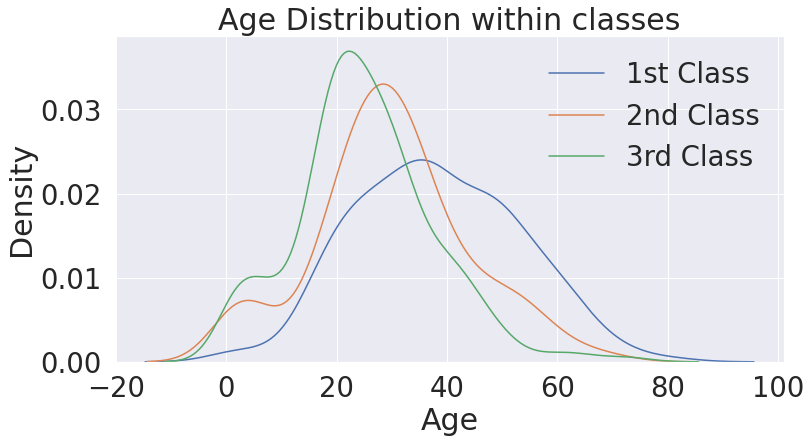

In [27]:
# 클래스 별 나이 분포도 (씨본)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.kdeplot(df_train[df_train['Pclass'] == 1]['Age'], ax=ax)
sns.kdeplot(df_train[df_train['Pclass'] == 2]['Age'], ax=ax)
sns.kdeplot(df_train[df_train['Pclass'] == 3]['Age'], ax=ax)
plt.title('Age Distribution within classes')
plt.legend(['1st Class', '2nd Class', '3rd Class'])
plt.show()

높은 클래스일 수록 나이의 분포도 우측으로 치우친다. 즉, 평균 나이가 높아진다. 10살 이하 구간을 보면 3클래스와 1클래스의 차이가 두드러진다. 

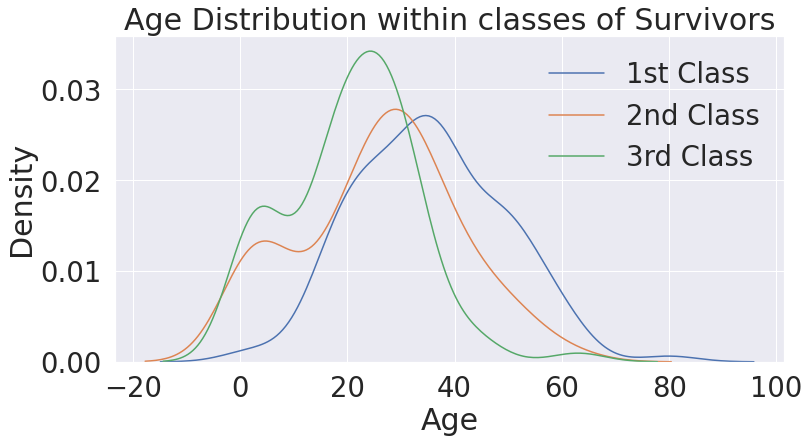

In [28]:
# 생존자의 클래스별 나이 분포도

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.kdeplot(df_train[(df_train['Pclass'] == 1) & (df_train['Survived'] == 1)]['Age'], ax=ax)
sns.kdeplot(df_train[(df_train['Pclass'] == 2) & (df_train['Survived'] == 1)]['Age'], ax=ax)
sns.kdeplot(df_train[(df_train['Pclass'] == 3) & (df_train['Survived'] == 1)]['Age'], ax=ax)
plt.title('Age Distribution within classes of Survivors')
plt.legend(['1st Class', '2nd Class', '3rd Class'])
plt.show()

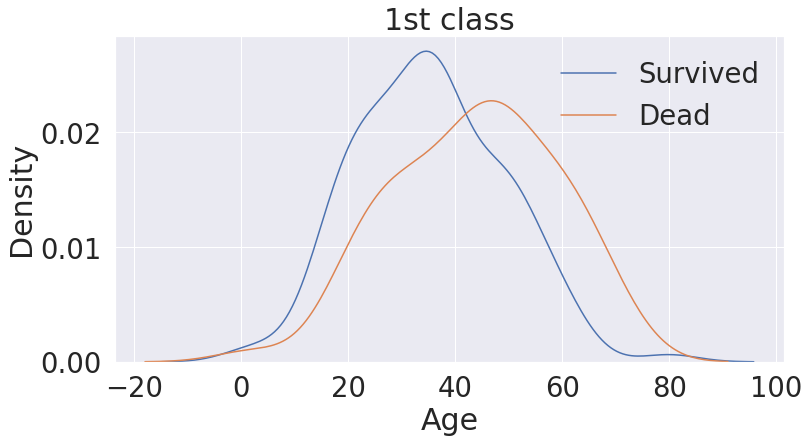

In [29]:
# 1st 클래스의 생존자와 사망자 나이 분포도
plt.figure(figsize=(12, 6))

sns.kdeplot(df_train[(df_train['Pclass'] == 1) & (df_train['Survived'] == 1)]['Age'])
sns.kdeplot(df_train[(df_train['Pclass'] == 1) & (df_train['Survived'] == 0)]['Age'])
plt.title('1st class')
plt.legend(['Survived', 'Dead'])
plt.show()

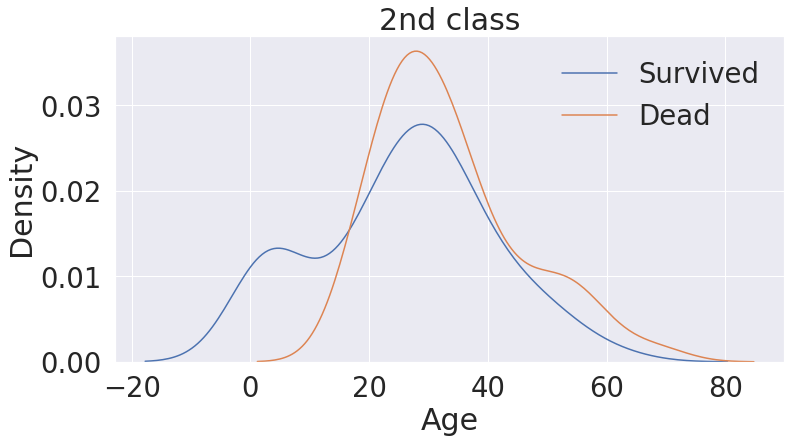

In [30]:
# 2nd 클래스의 생존자와 사망자 나이 분포도
plt.figure(figsize=(12, 6))

sns.kdeplot(df_train[(df_train['Pclass'] == 2) & (df_train['Survived'] == 1)]['Age'])
sns.kdeplot(df_train[(df_train['Pclass'] == 2) & (df_train['Survived'] == 0)]['Age'])
plt.title('2nd class')
plt.legend(['Survived', 'Dead'])
plt.show()

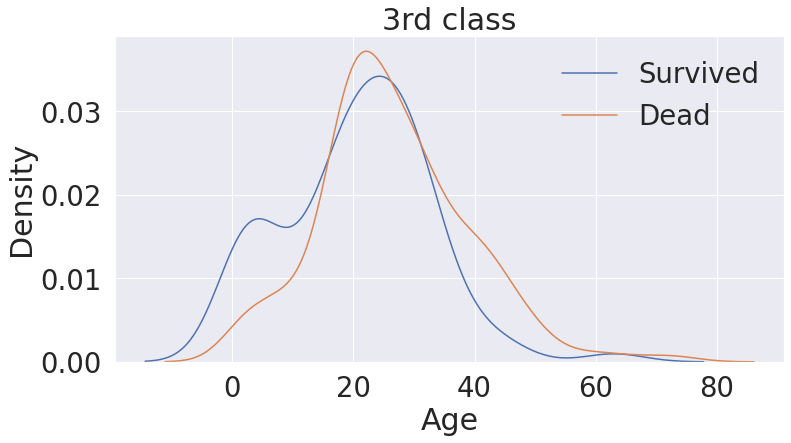

In [31]:
# 3rd 클래스의 생존자와 사망자 나이 분포도
plt.figure(figsize=(12, 6))

sns.kdeplot(df_train[(df_train['Pclass'] == 3) & (df_train['Survived'] == 1)]['Age'])
sns.kdeplot(df_train[(df_train['Pclass'] == 3) & (df_train['Survived'] == 0)]['Age'])
plt.title('3rd class')
plt.legend(['Survived', 'Dead'])
plt.show()

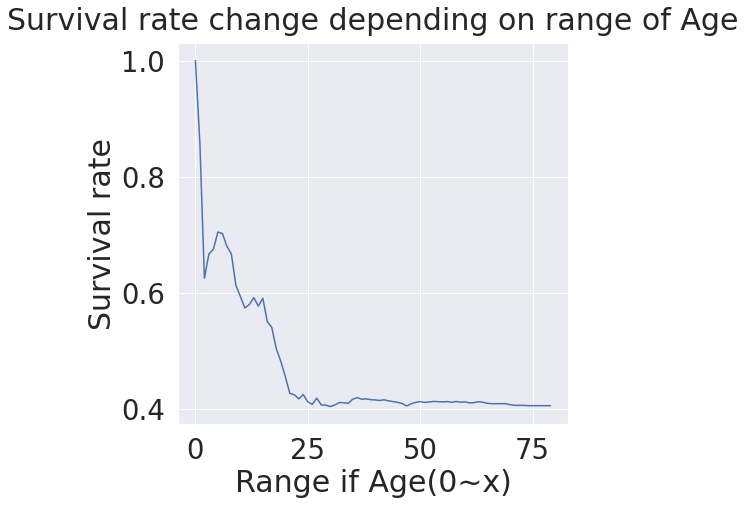

In [32]:
# 나이의 구간을 키워갈 수록 생존률 변화
change_age_range_survival_ratio = []

for i in range(1, 81):
    change_age_range_survival_ratio.append(df_train[df_train['Age'] < i]['Survived'].sum() / len(df_train[df_train['Age'] < i]['Survived']))
    
plt.figure(figsize=(7,7))
plt.plot(change_age_range_survival_ratio)
plt.title('Survival rate change depending on range of Age', y=1.02)
plt.ylabel('Survival rate')
plt.xlabel('Range if Age(0~x)')
plt.show()

In [33]:
# 열 살 미만의 생존자 수
i = 10
df_train[df_train['Age'] < i]['Survived'].sum()

38

In [34]:
# 10살 미만의 탑승객 수
len(df_train[df_train['Age'] < i]['Survived'])

62

In [35]:
# 10살 미만의 생존률
df_train[df_train['Age'] < i]['Survived'].sum() / len(df_train[df_train['Age'] < i]['Survived'])

0.6129032258064516

## Pclass, Sex, Age

클래스, 성별, 나이 3가지 특성을 가지고 관계를 분석한다.

### Violinplot
분포를 y축에 둘 수 있다. Pclass와 Sex는 범주형 데이터고 Age는 연속형자료이다. 연속형 자료는 분포를 확인한다.

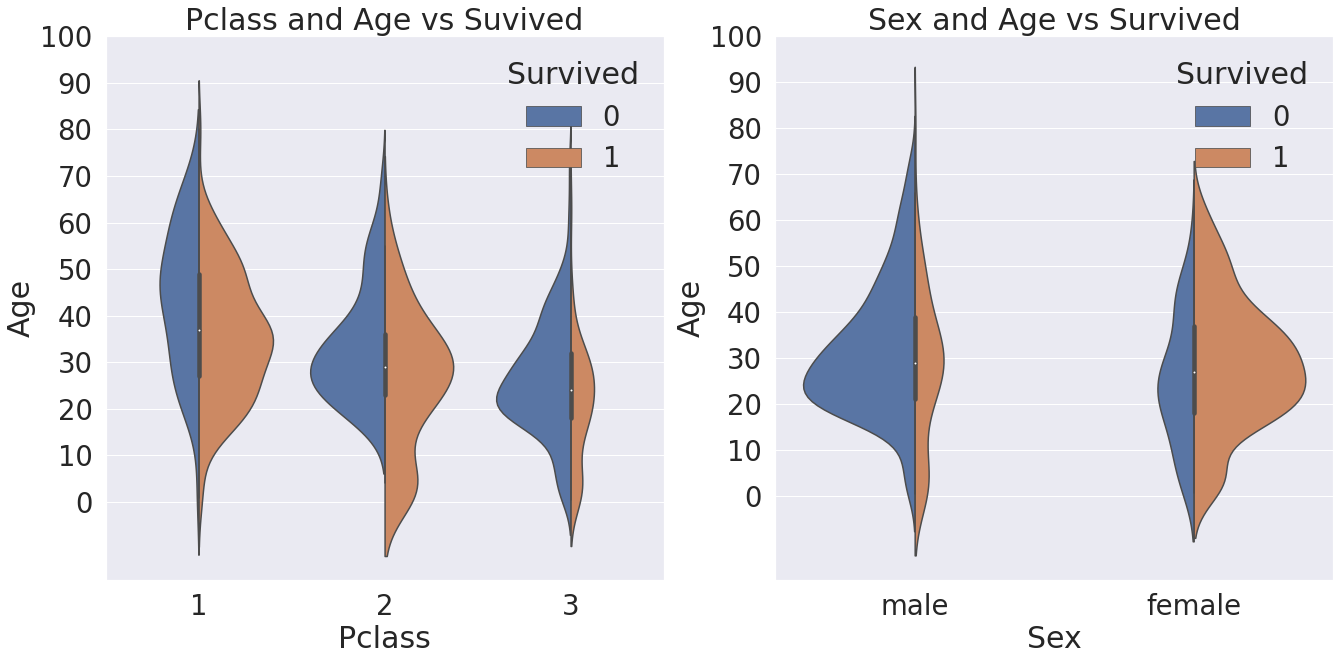

In [36]:
f, ax = plt.subplots(1, 2, figsize=(22, 10))

# 클래스 별 생존자와 사망자의 나이분포
sns.violinplot('Pclass', 'Age', hue='Survived', data=df_train, scale='count', split=True, ax=ax[0])
ax[0].set_title('Pclass and Age vs Suvived')
ax[0].set_yticks(range(0, 110, 10))

# 성별 별 생존자와 사망자의 나이분포
sns.violinplot('Sex', 'Age', hue='Survived', data=df_train, scale='count', split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))
plt.show()

In [37]:
# 생존자와 사망자의 평균 연령
survived_age_mean = df_train[df_train['Survived'] == 1]['Age'].mean()
dead_age_mean = df_train[df_train['Survived'] == 0]['Age'].mean()
print('생존자 평균나이는 {:.1f}세'.format(survived_age_mean))
print('사망자 평균나이는 {:.1f}세'.format(dead_age_mean))

생존자 평균나이는 28.3세
사망자 평균나이는 30.6세


In [38]:
# 클래스 별 생존자와 사망자의 평균 연령
for i in range(1, 4):
    fs = df_train[(df_train['Pclass'] == i) & (df_train['Survived'] == 1)]['Age'].mean()
    fd = df_train[(df_train['Pclass'] == i) & (df_train['Survived'] == 0)]['Age'].mean()
    print('{}등석 생존자 평균나이는 {:.1f}세'.format(i, fs))
    print('{}등석 사망자 평균나이는 {:.1f}세 \n'.format(i, fd))

1등석 생존자 평균나이는 35.4세
1등석 사망자 평균나이는 43.7세 

2등석 생존자 평균나이는 25.9세
2등석 사망자 평균나이는 33.5세 

3등석 생존자 평균나이는 20.6세
3등석 사망자 평균나이는 26.6세 



## Embarked

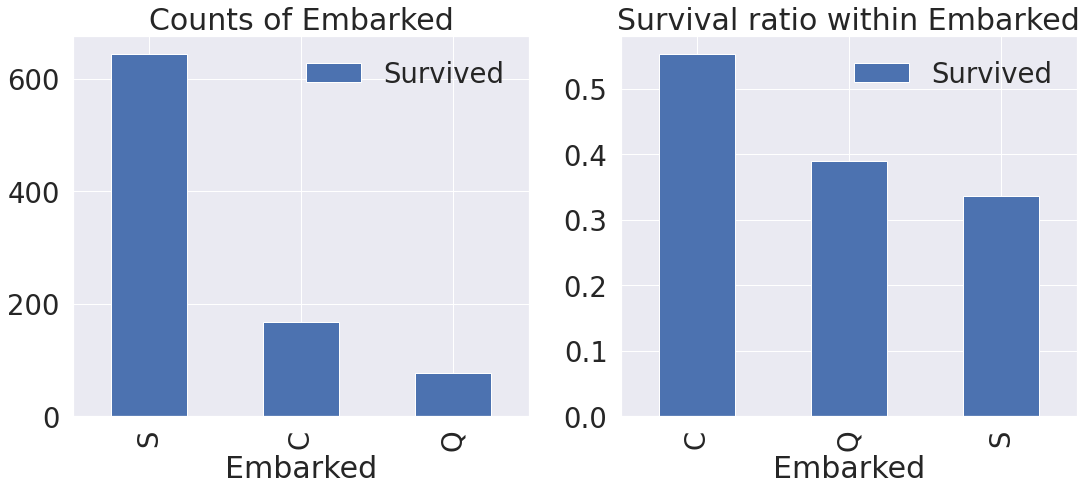

In [39]:
f, ax = plt.subplots(1, 2, figsize=(18,7))
df_train[['Embarked', 'Survived']].groupby(['Embarked'], as_index=True).count().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[0])
ax[0].set_title('Counts of Embarked')
df_train[['Embarked', 'Survived']].groupby(['Embarked'], as_index=True).mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[1])
ax[1].set_title('Survival ratio within Embarked')
plt.show()

In [40]:
# 탑승 위치별 생존자와 사망자 수
pd.crosstab(df_train['Embarked'], df_train['Survived'], margins=True).style.background_gradient(cmap='Blues')

Survived,0,1,All
Embarked,,,
C,75,93,168
Q,47,30,77
S,427,217,644
All,549,340,889


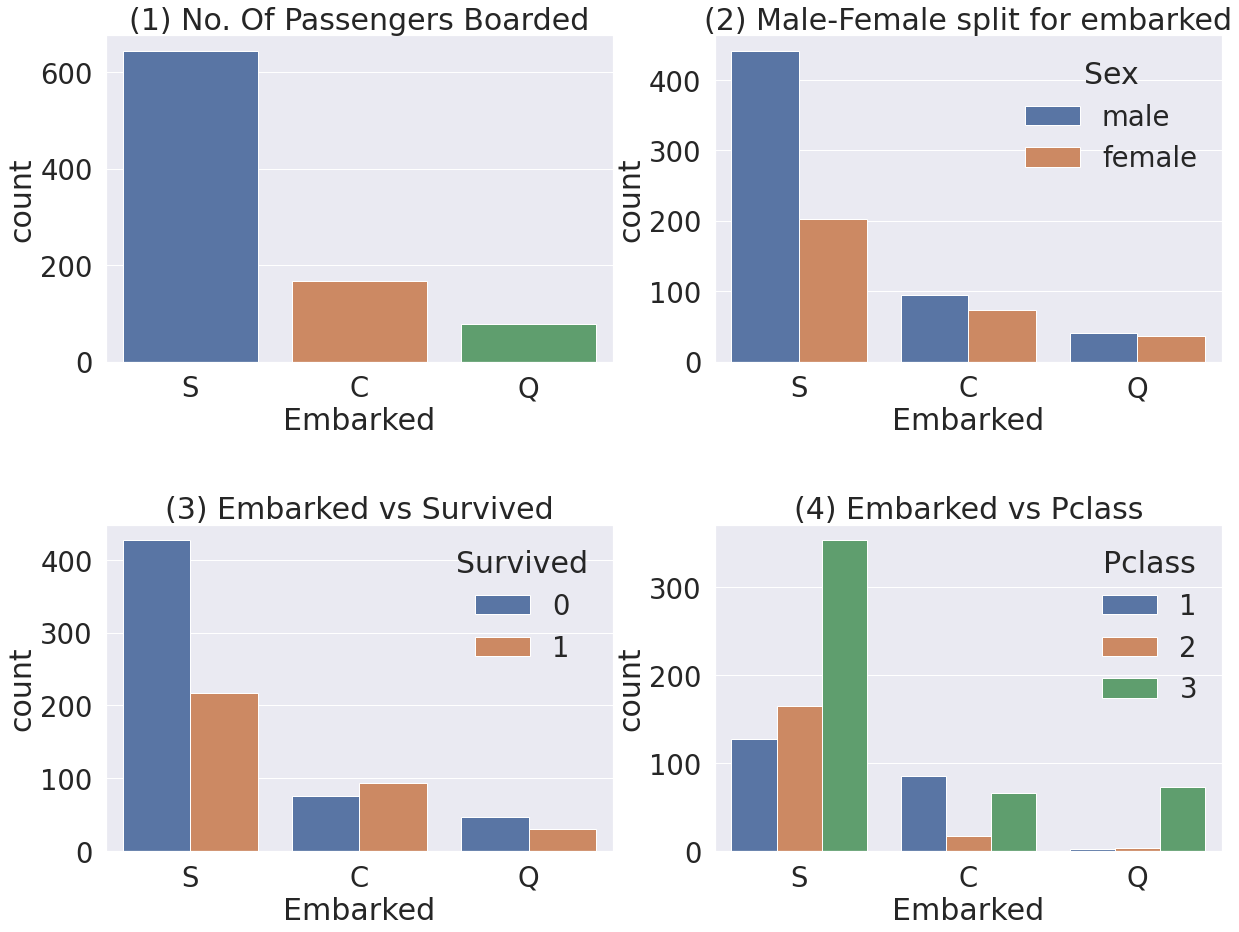

In [41]:
f, ax = plt.subplots(2, 2, figsize=(20, 15))

sns.countplot('Embarked', data=df_train, ax=ax[0,0])
ax[0,0].set_title('(1) No. Of Passengers Boarded')

sns.countplot('Embarked', hue='Sex', data=df_train, ax=ax[0,1])
ax[0, 1].set_title('(2) Male-Female split for embarked')

sns.countplot('Embarked', hue='Survived', data=df_train, ax=ax[1,0])
ax[1,0].set_title('(3) Embarked vs Survived')

sns.countplot('Embarked', hue='Pclass', data=df_train, ax=ax[1,1])
ax[1,1].set_title('(4) Embarked vs Pclass')

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Family = SibSp + Parch

형제자매와 부모를 합쳐서 가족 열을 만든다.

In [42]:
# 가족 열 생성. 마지막 1은 자기 자신을 포함하기 위해서
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

In [43]:
print('Maximum size of Family', df_train['FamilySize'].max())
print('Minimum size of Family', df_train['FamilySize'].min())

Maximum size of Family 11
Minimum size of Family 1


In [44]:
no_fam = df_train[df_train['FamilySize'] == 1].shape[0] / df_train['FamilySize'].shape[0]
print(f'탑승객중 가족이 없는 사람의 비율 : {100 * no_fam:.1f}%')

탑승객중 가족이 없는 사람의 비율 : 60.3%


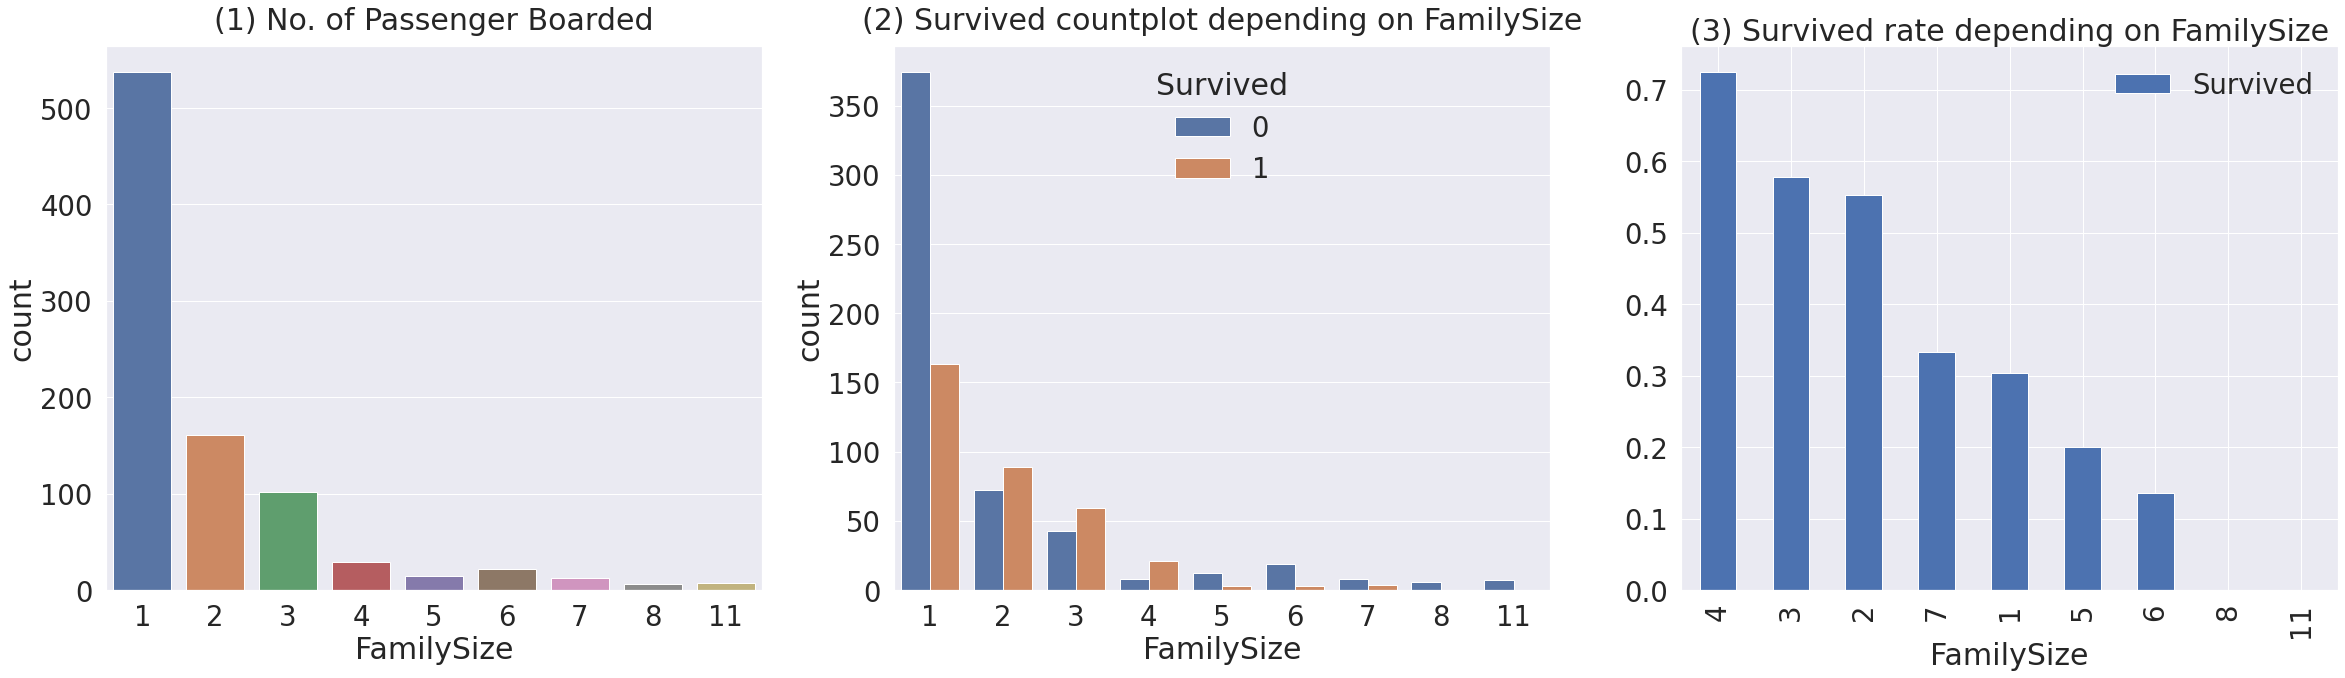

In [45]:
# 함께 탑승한 가족수 별로 그래프
f, ax = plt.subplots(1, 3, figsize=(40, 10))

# 가족수 별 그래프
sns.countplot('FamilySize', data=df_train, ax=ax[0])
ax[0].set_title('(1) No. of Passenger Boarded', y=1.02)

# 가족수 별 생존자와 사망자
sns.countplot('FamilySize', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('(2) Survived countplot depending on FamilySize', y=1.02)

# 가족수 별 사망률
df_train[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=True).mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[2])
ax[2].set_title('(3) Survived rate depending on FamilySize')

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Fare

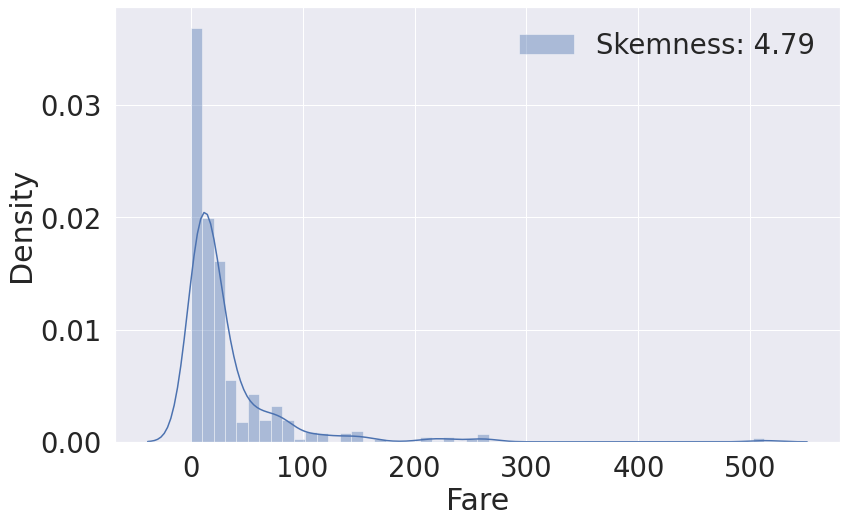

In [46]:
# 요금 데이터의 분포도 확인
fig, ax = plt.subplots(1, 1, figsize=(13, 8))
g = sns.distplot(df_train['Fare'], color='b', label='Skemness: {:.2f}'.format(df_train['Fare'].skew()), ax=ax)
g = g.legend(loc='best')

- skewness는 왜도이다. 정규분표에서 얼마나 좌우로 치우쳐져있는지를 나타낸다. 절대값 3미만이면 괜찮다. skewnees를 절대값 3이하로 줄이는 작업을 해줘야 한다.

- kurtosis는 첨도이다. 첨도가 클 수록 그래프가 뾰족해진다. 첨도가 클 수록 이상치가 많다. 절대값 7미만이면 괜찮다.

In [47]:
# 왜도를 줄이기 위해 로그를 취한다.
df_train['Fare'] = df_train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

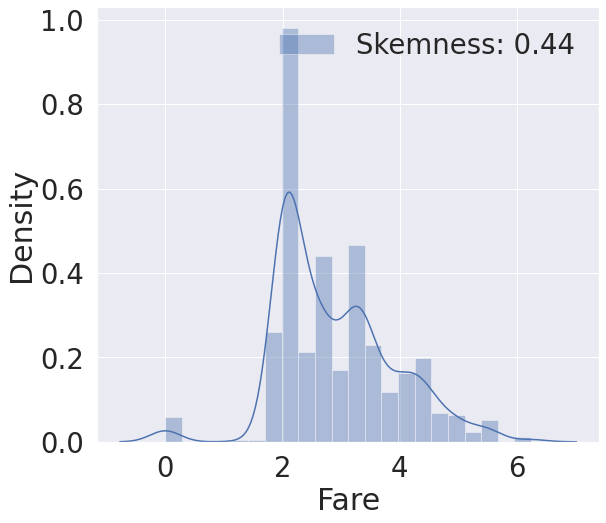

In [48]:
# 요금 데이터의 분포도 확인 (로그를 취한 뒤)
fig, ax = plt.subplots(1, 1, figsize=(9, 8))
g = sns.distplot(df_train['Fare'], color='b', label='Skemness: {:.2f}'.format(df_train['Fare'].skew()), ax=ax)
g = g.legend(loc='best')

In [49]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,NaN,S,1


캐빈은 결측치가 너무 많기 때문에 사용하지 않고 티켓은 잘 이용하면 모델의 성능을 더 높일 수 있다. 지금은 사용하지 않는다.

# Feature engineering

나이의 결측치를 수정해준다.

In [50]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [51]:
df_train['Age'].isnull().sum()

177

나이 특성을 보면 결측치가 177개 있다. 이를 어떤 식으로 든 가공해줘야 한다. 승객들의 이름을 보면 Mr.나 Mrs. 같은 호칭을 볼 수 있다. 이 호칭을 이용해서 같은 호칭을 사용하는 사람들끼리 짝지어서 나이를 예측해서 데이터를 채워본다.

정규표현식을 사용해서 호칭만 골라본다.

In [52]:
# 단어 뒤어 '.'가 붙은 단어를 추출해서 컬럼으로 만든다.
df_train['Initial'] = df_train['Name'].str.extract('([A-Za-z]+)\.')
df_test['Initial'] = df_train['Name'].str.extract('([A-za-z]+)\.')

In [53]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,NaN,S,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,NaN,S,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,NaN,S,1,Mr


In [54]:
pd.crosstab(df_train['Initial'], df_train['Sex']).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


호칭이 여러개인 것을 볼 수 있다. 이 호칭들을 성별에 맞게 가지수를 줄여준다.

In [55]:
df_train['Initial'].replace(['Capt', 'Col', 'Countess', 'Don', 'Dr', 'Jonkheer', 'Lady', 'Major', 'Mlle', 'Mme', 'Ms', 'Rev', 'Sir'], 
                               ['Mr', 'Other', 'Mrs', 'Mr', 'Mr', 'Other', 'Mrs', 'Mr', 'Miss', 'Miss', 'Miss', 'Other', 'Mr'], inplace=True)

df_test['Initial'].replace(['Capt', 'Col', 'Countess', 'Don', 'Dr', 'Jonkheer', 'Lady', 'Major', 'Mlle', 'Mme', 'Ms', 'Rev', 'Sir'], 
                               ['Mr', 'Other', 'Mrs', 'Mr', 'Mr', 'Other', 'Mrs', 'Mr', 'Miss', 'Miss', 'Miss', 'Other', 'Mr'], inplace=True)

In [56]:
df_train['Initial'].value_counts()

Mr        529
Miss      186
Mrs       127
Master     40
Other       9
Name: Initial, dtype: int64

In [57]:
# 이니셜 결측치 확인
print(df_train['Initial'].isnull().sum())
print(df_test['Initial'].isnull().sum())

0
0


In [58]:
# 지정한 컬럼을 행으로 두고 다른 행들의 값을 살펴본다.
df_train.groupby('Initial').mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Initial,,,,,,,,
Master,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,3.340710,4.675000
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,3.123713,2.236559
Mr,455.880907,0.162571,2.381853,32.739609,0.293006,0.151229,2.651507,1.444234
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,3.443751,2.511811
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,2.641605,1.222222


<AxesSubplot:xlabel='Initial'>

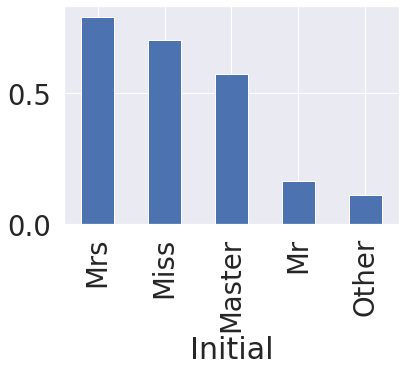

In [59]:
# 호칭별 생존률 파악
df_train.groupby('Initial', as_index=True)['Survived'].mean().sort_values(ascending=False).plot.bar()

In [60]:
# 호칭별 평균 나이를 구했다.
df_train.groupby('Initial').mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Initial,,,,,,,,
Master,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,3.340710,4.675000
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,3.123713,2.236559
Mr,455.880907,0.162571,2.381853,32.739609,0.293006,0.151229,2.651507,1.444234
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,3.443751,2.511811
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,2.641605,1.222222


In [61]:
# # 호칭마다 결측치를 찾아서 훈련셋에서 찾은 평균값으로 변경한다.
df_train.loc[(df_train['Age'].isnull()) & (df_train['Initial'] == 'Master'), 'Age'] = 5
df_train.loc[(df_train['Age'].isnull()) & (df_train['Initial'] == 'Miss'), 'Age'] = 22
df_train.loc[(df_train['Age'].isnull()) & (df_train['Initial'] == 'Mr'), 'Age'] = 33
df_train.loc[(df_train['Age'].isnull()) & (df_train['Initial'] == 'Mrs'), 'Age'] = 36
df_train.loc[(df_train['Age'].isnull()) & (df_train['Initial'] == 'Other'), 'Age'] = 46

df_test.loc[(df_test['Age'].isnull()) & (df_test['Initial'] == 'Master'), 'Age'] = 5
df_test.loc[(df_test['Age'].isnull()) & (df_test['Initial'] == 'Miss'), 'Age'] = 22
df_test.loc[(df_test['Age'].isnull()) & (df_test['Initial'] == 'Mr'), 'Age'] = 33
df_test.loc[(df_test['Age'].isnull()) & (df_test['Initial'] == 'Mrs'), 'Age'] = 36
df_test.loc[(df_test['Age'].isnull()) & (df_test['Initial'] == 'Other'), 'Age'] = 46

In [62]:
# 다시 결측치 확인
print(df_train.info())
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  Initial      891 non-null    object 
dtypes: float64(2), int64(6), object(6)
memory usage: 97.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ---

## Embarked 결측치 수정

In [63]:
# 결측치 확인
df_train['Embarked'].isnull().sum()

2

결측치는 총 2개다. 2개의 결측치는 가장 많은 사람들이 승선한 지역으로 지정해준다.

In [64]:
df_train['Embarked'].fillna('S', inplace=True)
print('승선지 결측치 수정완료!')

승선지 결측치 수정완료!


In [65]:
# 다시 결측치 확인
df_train['Embarked'].isnull().sum()

0

## 나이를 카테고리로 만들어보기

In [66]:
# 새로운 컬럼 생성
df_train['Age_cat'] = 0

In [67]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Initial,Age_cat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,NaN,S,2,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,2,Mrs,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,NaN,S,1,Miss,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,2,Mrs,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,NaN,S,1,Mr,0


In [68]:
df_train.loc[df_train['Age'] < 10, 'Age_cat'] = 0
df_train.loc[(df_train['Age'] >= 10) & (df_train['Age'] < 20), 'Age_cat'] = 1
df_train.loc[(df_train['Age'] >= 20) & (df_train['Age'] < 30), 'Age_cat'] = 2
df_train.loc[(df_train['Age'] >= 30) & (df_train['Age'] < 40), 'Age_cat'] = 3
df_train.loc[(df_train['Age'] >= 40) & (df_train['Age'] < 50), 'Age_cat'] = 4
df_train.loc[(df_train['Age'] >= 50) & (df_train['Age'] < 60), 'Age_cat'] = 5
df_train.loc[(df_train['Age'] >= 60) & (df_train['Age'] < 70), 'Age_cat'] = 6
df_train.loc[df_train['Age'] >= 70, 'Age_cat'] = 7

In [69]:
df_test.loc[df_test['Age'] < 10, 'Age_cat'] = 0
df_test.loc[(df_test['Age'] >= 10) & (df_test['Age'] < 20), 'Age_cat'] = 1
df_test.loc[(df_test['Age'] >= 20) & (df_test['Age'] < 30), 'Age_cat'] = 2
df_test.loc[(df_test['Age'] >= 30) & (df_test['Age'] < 40), 'Age_cat'] = 3
df_test.loc[(df_test['Age'] >= 40) & (df_test['Age'] < 50), 'Age_cat'] = 4
df_test.loc[(df_test['Age'] >= 50) & (df_test['Age'] < 60), 'Age_cat'] = 5
df_test.loc[(df_test['Age'] >= 60) & (df_test['Age'] < 70), 'Age_cat'] = 6
df_test.loc[df_test['Age'] >= 70, 'Age_cat'] = 7

In [70]:
df_train['Age_cat'].value_counts()

3    304
2    256
1    102
4     89
0     66
5     48
6     19
7      7
Name: Age_cat, dtype: int64

In [71]:
df_test['Age_cat'].value_counts()

2.0    145
3.0    127
4.0     47
1.0     41
5.0     22
0.0     22
6.0     13
7.0      1
Name: Age_cat, dtype: int64